# 02 — Reference compatibility: can DMS and EVEscape mutation IDs be merged directly?

**The question.** The DMS was performed in **RSV-A Long** (a strain isolated in the 1950s). The
UAE EVEscape analysis is referenced against **KX858757.1** (hRSV/A isolate 13-005275, 2013). Both
sides label mutations as `<wt><position><mut>`, e.g. `K209N`. Whether `DMS K209N` and
`EVEscape K209N` denote *the same substitution at the same residue* is not something that may be
assumed — it must be established by sequence comparison. If it fails, the entire benchmark is
invalid.

**Result, up front:**

| Check | Outcome |
|---|---|
| Protein length | 574 aa on both sides |
| Insertions / deletions | **none** — the two sequences align gaplessly, 1:1 |
| Numbering offset | **none** — DMS `site` ≡ EVEscape `i` in the same 1..574 frame |
| Identity over the DMS window (sites 26–529) | 98.41% (496 / 504 positions agree) |
| Wildtype-residue disagreements inside the window | **8** — sites 80, 101, 105, 124, 213, 276, 384, 515 |
| Benchmark rows affected | **137 of 4,276 (3.20%)** — including all 15 substitutions at site 213, which is inside the nirsevimab epitope |

**Verdict: direct mutation-ID merging is valid**, conditional on explicit handling of the 8
reference-disagreement sites. This notebook produces that handling as a reusable merge function
plus a per-site compatibility table.

## Where the two references come from

| Side | Accession | Evidence |
|---|---|---|
| EVEscape (RSV-A) | **KX858757.1** | `rsv_global/F_protein_variants/rsv_f_train_scoring_scripts/escape_utils.py`: `REFERENCE_ACCESSION_BY_SUBTYPE = {"RSVA_F": "KX858757.1", "RSVB_F": "KX858756.1"}`; and the UAE preprint: *"reference isolates RSV A-NLD-13-005275 (GenBank accession KX858757.1)"* |
| DMS | RSV-A **Long** | Simonich et al.: *"the lab-adapted subtype A strain of RSV termed 'Long'"*; sequence from `RSV_Long_F_DMS/data/RSV_F_seqs/RSV-A_with_ref.fasta`, record 1 |

Both sequences are bundled in `../data/` so this notebook runs without either upstream repository.

## 1. Load the two reference sequences

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

DATA = Path("../data")
OUT = Path("../outputs")
OUT.mkdir(parents=True, exist_ok=True)


def read_fasta(path):
    # Minimal single-record FASTA reader: returns (header, sequence).
    header, parts = None, []
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if header is not None:
                break
            header = line[1:]
        else:
            parts.append(line)
    return header, "".join(parts).upper()


dms_hdr, DMS_REF = read_fasta(DATA / "RSV_Long_F_protein.fasta")
eve_hdr, EVE_REF = read_fasta(DATA / "KX858757.1_F_protein.fasta")

print("DMS reference      :", dms_hdr)
print("  length           :", len(DMS_REF))
print()
print("EVEscape reference :", eve_hdr)
print("  length           :", len(EVE_REF))

DMS reference      : RSV_Long_F | RSV-A Long strain fusion protein F | 574 aa | DMS reference (Simonich et al.) | source: RSV_Long_F_DMS@e01679c data/RSV_F_seqs/RSV-A_with_ref.fasta record 1
  length           : 574

EVEscape reference : KX858757.1 hRSV/A isolate 13-005275 fusion protein F | protein_id AOZ56961.1 | 574 aa | EVEscape RSV-A reference (rsv_global escape_utils.REFERENCE_ACCESSION_BY_SUBTYPE)
  length           : 574


## 2. Length and indel check

An offset or indel between the two references would silently shift every mutation ID and invalidate
the merge. This is the single highest-risk failure mode in the whole project, so it is tested first.

A gapless comparison is only legitimate if the sequences are the same length **and** a full
alignment introduces no gaps. Both are checked below: first the lengths, then a Needleman–Wunsch
alignment that would expose any indel if one existed.

In [2]:
def needleman_wunsch(a, b, match=2, mismatch=-1, gap=-2):
    # Global alignment; returns the gapped pair. Small sequences (574 aa), so the
    # quadratic DP is instant and avoids an external dependency.
    n, m = len(a), len(b)
    S = np.zeros((n + 1, m + 1), dtype=np.int32)
    B = np.zeros((n + 1, m + 1), dtype=np.int8)
    S[1:, 0] = np.arange(1, n + 1) * gap
    B[1:, 0] = 2
    S[0, 1:] = np.arange(1, m + 1) * gap
    B[0, 1:] = 3
    for i in range(1, n + 1):
        ai = a[i - 1]
        for j in range(1, m + 1):
            vals = (S[i - 1, j - 1] + (match if ai == b[j - 1] else mismatch),
                    S[i - 1, j] + gap,
                    S[i, j - 1] + gap)
            best = max(vals)
            S[i, j] = best
            B[i, j] = vals.index(best) + 1
    i, j, ga, gb = n, m, [], []
    while i > 0 or j > 0:
        d = B[i, j]
        if d == 1:
            ga.append(a[i - 1]); gb.append(b[j - 1]); i -= 1; j -= 1
        elif d == 2:
            ga.append(a[i - 1]); gb.append("-"); i -= 1
        else:
            ga.append("-"); gb.append(b[j - 1]); j -= 1
    return "".join(reversed(ga)), "".join(reversed(gb))


aln_dms, aln_eve = needleman_wunsch(DMS_REF, EVE_REF)

same_length = len(DMS_REF) == len(EVE_REF)
n_gaps = aln_dms.count("-") + aln_eve.count("-")

print("equal ungapped length      :", same_length, "({} vs {})".format(len(DMS_REF), len(EVE_REF)))
print("alignment length           :", len(aln_dms))
print("gaps introduced by aligning:", n_gaps)
print("alignment == ungapped pair :", aln_dms == DMS_REF and aln_eve == EVE_REF)

assert same_length, "reference lengths differ - a position mapping WOULD be required"
assert n_gaps == 0, "indels present - a position mapping IS required"

print("\n=> No insertions, no deletions, no numbering offset.")
print("=> Position i in RSV-A Long == position i in KX858757.1, for all i in 1..574.")

equal ungapped length      : True (574 vs 574)
alignment length           : 574
gaps introduced by aligning: 0
alignment == ungapped pair : True

=> No insertions, no deletions, no numbering offset.
=> Position i in RSV-A Long == position i in KX858757.1, for all i in 1..574.


## 3. Per-position wildtype comparison

Numbering compatibility is necessary but not sufficient. The two references can still carry
*different amino acids* at the same position. Where they do, a mutation ID means something
different on each side, and the merge key `(site, wt, mut)` will not match.

The DMS mutagenised the ectodomain, sites **26–529** in standard F numbering (position 1 = the
N-terminal Met). Only this window matters for the benchmark.

In [3]:
DMS_SITE_MIN, DMS_SITE_MAX = 26, 529

compat = pd.DataFrame({
    "site": np.arange(1, len(DMS_REF) + 1),
    "dms_wt": list(DMS_REF),
    "evescape_wt": list(EVE_REF),
})
compat["agree"] = compat.dms_wt == compat.evescape_wt
compat["in_dms_window"] = compat.site.between(DMS_SITE_MIN, DMS_SITE_MAX)

window = compat[compat.in_dms_window]
mismatches = window[~window.agree]

print("positions compared (full F)     : {}".format(len(compat)))
print("  disagreeing                   : {}".format((~compat.agree).sum()))
print()
print("positions in DMS window 26-529  : {}".format(len(window)))
print("  agreeing                      : {}  ({:.2%})".format(window.agree.sum(), window.agree.mean()))
print("  disagreeing                   : {}".format(len(mismatches)))

compat.to_csv(OUT / "reference_compatibility_by_site.csv", index=False)
print("\nwritten: outputs/reference_compatibility_by_site.csv  ({} rows)".format(len(compat)))

positions compared (full F)     : 574
  disagreeing                   : 11

positions in DMS window 26-529  : 504
  agreeing                      : 496  (98.41%)
  disagreeing                   : 8

written: outputs/reference_compatibility_by_site.csv  (574 rows)


In [4]:
outside = compat[(~compat.agree) & (~compat.in_dms_window)]

print("The 8 wildtype disagreements INSIDE the DMS window (Long -> KX858757.1):\n")
for _, r in mismatches.iterrows():
    print("   site {:3d}   DMS(Long) = {}   EVEscape(KX858757.1) = {}   -> {}{}{}".format(
        r.site, r.dms_wt, r.evescape_wt, r.dms_wt, r.site, r.evescape_wt))

print("\nFor completeness, {} further disagreements lie OUTSIDE the mutagenised window:".format(len(outside)))
for _, r in outside.iterrows():
    print("   site {:3d}   {} -> {}   (signal peptide / cytoplasmic tail; not measured by the DMS)".format(
        r.site, r.dms_wt, r.evescape_wt))

MISMATCH_SITES = sorted(mismatches.site.tolist())
print("\nMISMATCH_SITES =", MISMATCH_SITES)

The 8 wildtype disagreements INSIDE the DMS window (Long -> KX858757.1):

   site  80   DMS(Long) = N   EVEscape(KX858757.1) = K   -> N80K
   site 101   DMS(Long) = T   EVEscape(KX858757.1) = P   -> T101P
   site 105   DMS(Long) = N   EVEscape(KX858757.1) = S   -> N105S
   site 124   DMS(Long) = K   EVEscape(KX858757.1) = N   -> K124N
   site 213   DMS(Long) = R   EVEscape(KX858757.1) = S   -> R213S
   site 276   DMS(Long) = N   EVEscape(KX858757.1) = S   -> N276S
   site 384   DMS(Long) = V   EVEscape(KX858757.1) = I   -> V384I
   site 515   DMS(Long) = H   EVEscape(KX858757.1) = N   -> H515N

For completeness, 3 further disagreements lie OUTSIDE the mutagenised window:
   site   8   A -> T   (signal peptide / cytoplasmic tail; not measured by the DMS)
   site  20   F -> L   (signal peptide / cytoplasmic tail; not measured by the DMS)
   site 540   S -> A   (signal peptide / cytoplasmic tail; not measured by the DMS)

MISMATCH_SITES = [80, 101, 105, 124, 213, 276, 384, 515]


## 4. Independent cross-check of the numbering frame

The alignment above shows the two *sequences* share a frame. A second, fully independent check is
that the two *projects* also agree on what each position means biologically.

The DMS table annotates every site with a broadly defined antigenic region (`region_0` … `region_V`,
after Gilman 2016 / Rossey 2018). The UAE repository independently hard-codes antigenic-site
coordinate ranges in `escape_utils.ANTIGENIC_SITE_DATA`. If either side used a different numbering
origin, these two annotations would disagree wholesale.

In [5]:
# Coordinate ranges copied verbatim from
# rsv_global/F_protein_variants/rsv_f_train_scoring_scripts/escape_utils.py
ANTIGENIC_SITE_DATA = {
    "Site O":    [(62, 96), (195, 227)],
    "Site I":    [(27, 45), (312, 318), (378, 389)],
    "Site II":   [(254, 277)],
    "Site III":  [(46, 54), (301, 311), (345, 352), (367, 378)],
    "Site IV":   [(422, 471)],
    "Site V":    [(55, 61), (146, 194), (287, 300)],
    "P27 (FP)":  [(110, 136)],
}


def rsv_global_site(pos):
    for name, ranges in ANTIGENIC_SITE_DATA.items():
        for lo, hi in ranges:
            if lo <= pos <= hi:
                return name
    return "None"


benchmark = pd.read_csv(DATA / "dms_nirsevimab_functional.csv")
site_region = benchmark[["site", "region"]].drop_duplicates().sort_values("site")
site_region["rsv_global"] = site_region.site.map(rsv_global_site)

ct = pd.crosstab(site_region.region, site_region.rsv_global)
display(ct)

diag = sum(
    ct.loc[d, e]
    for d, e in [("region_0", "Site O"), ("region_I", "Site I"), ("region_II", "Site II"),
                 ("region_III", "Site III"), ("region_IV", "Site IV"), ("region_V", "Site V"),
                 ("none", "None"), ("none", "P27 (FP)")]
    if d in ct.index and e in ct.columns
)
print("\nsites annotated consistently by both projects: {} / {}  ({:.1%})".format(
    diag, len(site_region), diag / len(site_region)))
print("\nThe few off-diagonal entries are single-residue boundary-definition differences between")
print("the two source papers, not a numbering offset - an offset would scramble this table entirely.")

rsv_global,None,P27 (FP),Site I,Site II,Site III,Site IV,Site O,Site V
region,,,,,,,,
none,167,25,0,0,0,0,0,0
region_0,0,0,0,0,0,0,64,0
region_I,3,0,31,0,0,0,0,0
region_II,0,0,0,24,0,0,0,0
region_III,0,0,2,0,31,0,0,0
region_IV,0,0,0,0,0,40,0,0
region_V,0,0,0,0,0,0,1,68



sites annotated consistently by both projects: 450 / 456  (98.7%)

The few off-diagonal entries are single-residue boundary-definition differences between
the two source papers, not a numbering offset - an offset would scramble this table entirely.


## 5. Impact on the benchmark table

How many of the 4,276 benchmark rows sit at a reference-disagreement site, and what happens to them?

Two distinct cases arise:

1. **The DMS mutant equals the EVEscape wildtype.** For example, DMS `N80K` mutates Long's N80 to K —
   but K *is* the reference residue at position 80 in KX858757.1. EVEscape scores only *non-reference*
   substitutions, so no score can exist for this mutation, by construction.
2. **Everything else at those sites.** DMS `N80D` and EVEscape `K80D` both produce aspartate at
   position 80, but from different starting residues, in different genetic backgrounds. These are
   *different biochemical events* and must not be equated.

Both cases are dropped. Mapping them would require assuming the effect of a substitution is
independent of the residue it replaces — an assumption the DMS itself contradicts (Simonich et al.
show S211R has opposite signs in the Long and B1 backgrounds).

In [6]:
eve_wt_by_site = dict(zip(compat.site, compat.evescape_wt))

benchmark["evescape_wt"] = benchmark.site.map(eve_wt_by_site)
benchmark["reference_agrees"] = benchmark.wildtype == benchmark.evescape_wt
benchmark["mutant_is_evescape_reference"] = benchmark.mutant == benchmark.evescape_wt

affected = benchmark[~benchmark.reference_agrees]
case1 = affected[affected.mutant_is_evescape_reference]
case2 = affected[~affected.mutant_is_evescape_reference]

print("benchmark rows                          : {}".format(len(benchmark)))
print("  mergeable (reference residues agree)  : {}".format(benchmark.reference_agrees.sum()))
print("  dropped (reference disagreement)      : {}  ({:.2%})".format(
    len(affected), len(affected) / len(benchmark)))
print("      case 1: mutant == EVEscape wt     : {}".format(len(case1)))
print("      case 2: other muts at those sites : {}".format(len(case2)))
print("\nrows per disagreement site:")
print(affected.groupby("site").size().to_string())

benchmark rows                          : 4276
  mergeable (reference residues agree)  : 4139
  dropped (reference disagreement)      : 137  (3.20%)
      case 1: mutant == EVEscape wt     : 7
      case 2: other muts at those sites : 130

rows per disagreement site:
site
80     16
101    18
105    19
124    19
213    15
276    18
384    18
515    14


In [7]:
print("Case 1 - the reference-swap mutations themselves (no EVEscape score can exist):\n")
display(case1[["mutation", "site", "wildtype", "mutant", "evescape_wt",
               "Nirsevimab-Fab escape", "Nirsevimab-IgG escape", "cell entry", "region"]])

print("\nHow much escape signal is lost? (escape is the POSITIVE direction; report it directionally)\n")
fab_all = benchmark["Nirsevimab-Fab escape"].dropna()
for col in ["Nirsevimab-Fab escape", "Nirsevimab-IgG escape"]:
    v = affected[col].dropna()
    print("  {:24s} n={:3d}   max (escape dir) = {:+.3f}   min = {:+.3f}".format(
        col, len(v), v.max(), v.min()))

worst = affected.loc[affected["Nirsevimab-Fab escape"].idxmax()]
pct = (fab_all < worst["Nirsevimab-Fab escape"]).mean()
print("\n  strongest dropped escape mutation: {} (Fab {:+.3f}) = {:.1%} percentile of the benchmark".format(
    worst.mutation, worst["Nirsevimab-Fab escape"], pct))
print("  benchmark rows with Fab escape > 1.0 (the strong-escape tail): {}".format((fab_all > 1.0).sum()))
print("  of those, dropped: {}".format((affected["Nirsevimab-Fab escape"] > 1.0).sum()))

epitope_sites = [s for s in MISMATCH_SITES if 64 <= s <= 73 or 201 <= s <= 216]
in_epi = affected[affected.site.isin(epitope_sites)]
print("\n  IMPORTANT: site 213 lies INSIDE the nirsevimab epitope (201-216).")
print("  disagreement sites in the epitope : {}".format(epitope_sites))
print("  benchmark rows lost there         : {}  (all site-213 substitutions, region_0)".format(len(in_epi)))
print("  their maximum Fab escape          : {:+.3f}".format(in_epi["Nirsevimab-Fab escape"].max()))
print("\n=> The loss is NOT confined to irrelevant regions: an entire epitope site is removed.")
print("   No dropped row reaches the strong-escape tail (Fab > 1.0), so the top of the ranking is")
print("   unaffected, but site 213 must be named explicitly as a coverage gap when reporting.")

affected.drop(columns=["mutant_is_evescape_reference"]).to_csv(
    OUT / "reference_mismatch_dropped_rows.csv", index=False)
print("\nwritten: outputs/reference_mismatch_dropped_rows.csv ({} rows)".format(len(affected)))

Case 1 - the reference-swap mutations themselves (no EVEscape score can exist):



,mutation,site,wildtype,mutant,evescape_wt,Nirsevimab-Fab escape,Nirsevimab-IgG escape,cell entry,region
469,N80K,80,N,K,K,-0.56070,-0.66520,-1.0050,region_0
747,N105S,105,N,S,S,0.04048,0.21180,-0.5333,none
1058,K124N,124,K,N,N,0.30280,-0.08751,0.1590,none
1917,R213S,213,R,S,S,0.65550,-0.51460,-1.0910,region_0
2424,N276S,276,N,S,S,0.06759,-0.15570,0.6924,region_II
3165,V384I,384,V,I,I,-0.18330,0.09362,-0.2802,region_I
4102,H515N,515,H,N,N,-0.15470,0.06667,-0.7768,none



How much escape signal is lost? (escape is the POSITIVE direction; report it directionally)

  Nirsevimab-Fab escape    n=132   max (escape dir) = +0.752   min = -1.643
  Nirsevimab-IgG escape    n=137   max (escape dir) = +0.387   min = -0.665

  strongest dropped escape mutation: V384T (Fab +0.752) = 97.0% percentile of the benchmark
  benchmark rows with Fab escape > 1.0 (the strong-escape tail): 98
  of those, dropped: 0

  IMPORTANT: site 213 lies INSIDE the nirsevimab epitope (201-216).
  disagreement sites in the epitope : [213]
  benchmark rows lost there         : 15  (all site-213 substitutions, region_0)
  their maximum Fab escape          : +0.655

=> The loss is NOT confined to irrelevant regions: an entire epitope site is removed.
   No dropped row reaches the strong-escape tail (Fab > 1.0), so the top of the ranking is
   unaffected, but site 213 must be named explicitly as a coverage gap when reporting.

written: outputs/reference_mismatch_dropped_rows.csv (137 rows)


## 6. Merge-key specification

This is the contract the EVEscape table has to satisfy.

**Key:** `(DMS.site, DMS.wildtype, DMS.mutant)` <-> `(EVEscape.i, EVEscape.wt, EVEscape.mut)`

| DMS column | EVEscape column | Note |
|---|---|---|
| `site` | `i` | Standard RSV F numbering, 1 = N-terminal Met, identical frame (proven in section 2) |
| `wildtype` | `wt` | Must agree; the 8 sites where they do not are dropped |
| `mutant` | `mut` | — |

**Do not** merge on `sequential_site` — it is ectodomain-relative (`site - 25`) and would introduce a
25-position shift.

**Join semantics:** `how="left"` from the DMS side with `validate="one_to_one"`. A left join keeps
unmatched DMS rows visible as `NaN` so coverage can be measured; an inner join would silently hide
the loss. `one_to_one` is expected to pass because both keys are unique on their own side
(DMS: verified in notebook 01; EVEscape: one row per (i, wt, mut) across 574 x 19 = 10,906 rows).

**Coverage metrics to report** with any benchmark result:

* `n_dms_benchmark` — rows in; `n_merged` — rows with an EVEscape score
* `n_dropped_reference_mismatch` — the 8-site loss, expected to be 137
* `n_dropped_out_of_range` — DMS sites outside the EVEscape 1..574 range (expected 0)
* `n_dropped_not_scored` — key agrees, but absent from the EVEscape table
* `n_evescape_unused` — EVEscape rows with no DMS counterpart (expected to be large: the DMS covers
  only the ectodomain, and not exhaustively)

In [8]:
def merge_dms_evescape(dms, evescape, reference_wt_by_site=None):
    # Merge a DMS benchmark table with an RSV-A EVEscape score table and return
    # (merged_frame, coverage_report). Every dropped row is accounted for by category.
    required = {"i", "wt", "mut"}
    missing = required - set(evescape.columns)
    if missing:
        raise ValueError("EVEscape table missing columns: {}".format(sorted(missing)))

    if evescape.duplicated(["i", "wt", "mut"]).any():
        raise ValueError("EVEscape table has duplicate (i, wt, mut) keys")
    if dms.duplicated(["site", "wildtype", "mutant"]).any():
        raise ValueError("DMS table has duplicate (site, wildtype, mutant) keys")

    eve_range = (int(evescape.i.min()), int(evescape.i.max()))
    score_cols = [c for c in evescape.columns if c not in {"i", "wt", "mut"}]

    merged = dms.merge(
        evescape.rename(columns={"i": "site", "wt": "wildtype", "mut": "mutant"}),
        on=["site", "wildtype", "mutant"],
        how="left",
        validate="one_to_one",
    )

    probe = score_cols[0]
    matched = merged[probe].notna()

    if reference_wt_by_site is None:
        reference_wt_by_site = dict(zip(evescape.i, evescape.wt))
    ref_wt = merged.site.map(reference_wt_by_site)
    ref_mismatch = ref_wt.notna() & (ref_wt != merged.wildtype)
    out_of_range = ~merged.site.between(*eve_range)

    report = {
        "n_dms_benchmark": len(dms),
        "n_merged": int(matched.sum()),
        "n_dropped_reference_mismatch": int((~matched & ref_mismatch).sum()),
        "n_dropped_out_of_range": int((~matched & ~ref_mismatch & out_of_range).sum()),
        "n_dropped_not_scored": int((~matched & ~ref_mismatch & ~out_of_range).sum()),
        "n_evescape_rows": len(evescape),
        "n_evescape_unused": len(evescape) - int(matched.sum()),
        "coverage": float(matched.mean()),
        "evescape_site_range": eve_range,
    }
    assert (report["n_merged"] + report["n_dropped_reference_mismatch"]
            + report["n_dropped_out_of_range"] + report["n_dropped_not_scored"]) == len(dms)
    return merged, report


print("merge_dms_evescape() defined - every input row is accounted for by construction.")

merge_dms_evescape() defined - every input row is accounted for by construction.


## 7. Dry run against a schema stub

The production RSV-A EVEscape table is **not available** (only a 3-mutation toy example ships with
`rsv_global`). To verify the merge machinery end-to-end *now* — and to document exactly what schema is
expected — the cell below builds a stub with the correct shape:
574 positions x 19 non-reference substitutions = **10,906 rows**, wildtype residues taken from
KX858757.1.

> **The `evescape` values in this stub are pseudo-random placeholders.**
> They are here to exercise the join and the coverage accounting. **No result computed from this
> stub carries any scientific meaning.** Replace the stub with the production table and re-run.

In [9]:
AA20 = "ACDEFGHIKLMNPQRSTVWY"
rng = np.random.default_rng(0)  # fixed seed: the stub is deterministic and obviously synthetic

rows = []
for pos, wt in enumerate(EVE_REF, start=1):
    for mut in AA20:
        if mut == wt:
            continue
        rows.append((wt + str(pos) + mut, wt, pos, mut))

stub = pd.DataFrame(rows, columns=["mutation", "wt", "i", "mut"])
stub["evescape"] = rng.normal(size=len(stub))                      # PLACEHOLDER - not real scores
stub["evescape_composite"] = np.exp(stub.evescape)
stub["evescape_percentile"] = stub.evescape.rank(method="average", pct=True)

print("stub rows          : {}   (expected 574 x 19 = {})".format(len(stub), 574 * 19))
print("positions          : {}".format(stub.i.nunique()))
print("substitutions/site : {}".format(stub.groupby("i").size().unique()))
print("unique (i,wt,mut)  : {}".format(not stub.duplicated(["i", "wt", "mut"]).any()))
assert len(stub) == 10906
display(stub.head(3))

stub rows          : 10906   (expected 574 x 19 = 10906)
positions          : 574
substitutions/site : [19]
unique (i,wt,mut)  : True


,mutation,wt,i,mut,evescape,evescape_composite,evescape_percentile
0,M1A,M,1,A,0.125730,1.133976,0.548139
1,M1C,M,1,C,-0.132105,0.876249,0.450761
2,M1D,M,1,D,0.640423,1.897283,0.734183


In [10]:
bench_cols = ["mutation", "site", "wildtype", "mutant",
              "Nirsevimab-Fab escape", "Nirsevimab-IgG escape", "cell entry", "region"]
merged, report = merge_dms_evescape(benchmark[bench_cols], stub.drop(columns=["mutation"]))

print("MERGE COVERAGE REPORT (schema stub - scores are placeholders)\n")
for k, v in report.items():
    print("  {:32s} {}".format(k, v))

print("\nvalidate='one_to_one' passed.")
print("dropped-row accounting is exact: {} + {} + {} + {} = {}".format(
    report["n_merged"], report["n_dropped_reference_mismatch"],
    report["n_dropped_out_of_range"], report["n_dropped_not_scored"],
    report["n_dms_benchmark"]))

assert report["n_merged"] == 4139
assert report["n_dropped_reference_mismatch"] == 137
assert report["n_dropped_out_of_range"] == 0

MERGE COVERAGE REPORT (schema stub - scores are placeholders)

  n_dms_benchmark                  4276
  n_merged                         4139
  n_dropped_reference_mismatch     137
  n_dropped_out_of_range           0
  n_dropped_not_scored             0
  n_evescape_rows                  10906
  n_evescape_unused                6767
  coverage                         0.9679607109448082
  evescape_site_range              (1, 574)

validate='one_to_one' passed.
dropped-row accounting is exact: 4139 + 137 + 0 + 0 = 4276


## 8. Figure — where the two references disagree

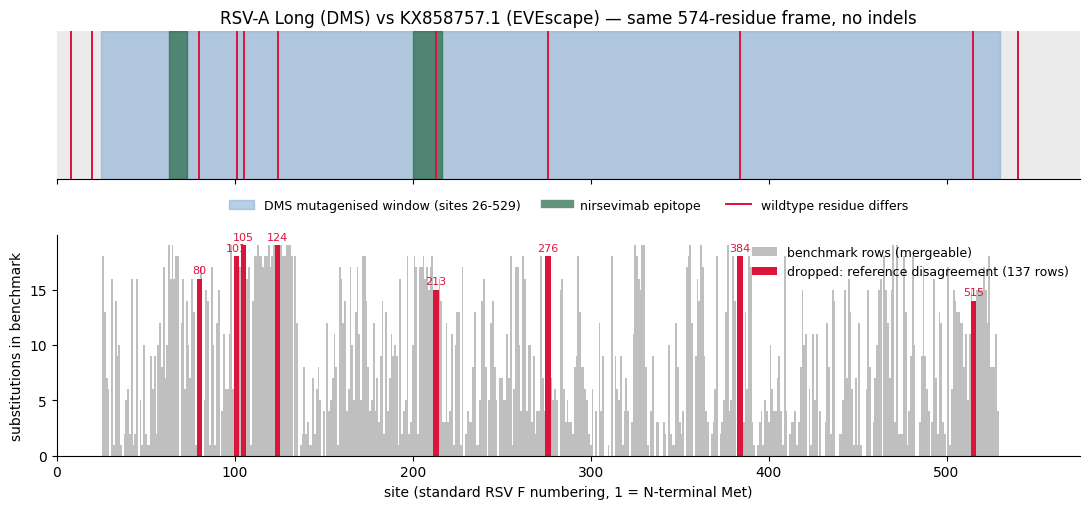

In [11]:
import matplotlib.pyplot as plt

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 5.2),
                               gridspec_kw={"height_ratios": [1, 1.5]}, sharex=True)

# --- top: schematic of the F protein with the DMS window and the disagreements ---
ax0.axhspan(0, 1, xmin=0, xmax=1, color="0.92")
ax0.axhspan(0, 1,
            xmin=(DMS_SITE_MIN - 1) / 574, xmax=DMS_SITE_MAX / 574,
            color="#7fa8d1", alpha=0.55,
            label="DMS mutagenised window (sites {}-{})".format(DMS_SITE_MIN, DMS_SITE_MAX))
for lo, hi in [(64, 73), (201, 216)]:
    ax0.axhspan(0, 1, xmin=(lo - 1) / 574, xmax=hi / 574, color="#2f6f4f", alpha=0.75)
ax0.plot([], [], color="#2f6f4f", lw=6, alpha=0.75, label="nirsevimab epitope")
for s in compat.loc[~compat.agree, "site"]:
    ax0.axvline(s, color="crimson", lw=1.4)
ax0.plot([], [], color="crimson", lw=1.4, label="wildtype residue differs")
ax0.set_ylim(0, 1)
ax0.set_yticks([])
ax0.set_title("RSV-A Long (DMS) vs KX858757.1 (EVEscape) — same 574-residue frame, no indels")
ax0.legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=3, frameon=False, fontsize=9)
for sp in ["top", "right", "left"]:
    ax0.spines[sp].set_visible(False)

# --- bottom: benchmark rows per site, dropped ones highlighted ---
per_site = benchmark.groupby("site").size()
ax1.bar(per_site.index, per_site.values, width=1.0, color="0.75", label="benchmark rows (mergeable)")
drop = affected.groupby("site").size()
ax1.bar(drop.index, drop.values, width=3.0, color="crimson",
        label="dropped: reference disagreement ({} rows)".format(len(affected)))
for s, n in drop.items():
    ax1.annotate(str(s), (s, n), textcoords="offset points", xytext=(0, 4),
                 ha="center", fontsize=8, color="crimson")
ax1.set_xlabel("site (standard RSV F numbering, 1 = N-terminal Met)")
ax1.set_ylabel("substitutions in benchmark")
ax1.set_xlim(0, 575)
ax1.legend(frameon=False, fontsize=9)
for sp in ["top", "right"]:
    ax1.spines[sp].set_visible(False)

fig.tight_layout()
fig.savefig(OUT / "fig02_reference_compatibility.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Summary and what this means for the collaboration

**The critical risk is resolved.** RSV-A Long F and KX858757.1 F are both 574 residues, align
gaplessly, and carry no numbering offset. `DMS K209N` and `EVEscape K209N` refer to the same
substitution at the same residue — this is now *verified*, not assumed. The merge can proceed
without a position-mapping step.

**The residual risk is wildtype identity, not numbering.** The two references differ at 8 positions
inside the mutagenised window (80, 101, 105, 124, 213, 276, 384, 515), accounting for
**137 of 4,276 benchmark rows (3.20%)**, which are dropped with the count reported.

**One of those sites — 213 — lies inside the nirsevimab epitope (201–216)**, so all 15 site-213
substitutions are lost from the benchmark. This is a real coverage gap and must be named when the
result is reported, not absorbed into a percentage. Its practical severity is limited: the
strongest escape mutation among the dropped rows is `V384T` at Fab `+0.752` (97th percentile), and
**no dropped row reaches the strong-escape tail** (Fab > 1.0, n = 98), so the top of the ranking —
the part that matters for top-k enrichment — is untouched.

**Expected merge coverage: 4,139 of 4,276 rows (96.80%), with site 213 absent.**

### What is still needed

The benchmark cannot be run until the production RSV-A EVEscape scores are available. `rsv_global`
ships only a 3-mutation toy example (`toy_examples/evescape_minimal/`), and a full history search of
that repository confirms no production data has ever been committed — the largest object in its
entire git history is a 33 KB Python script.

**Preferred:** the final RSV-A per-mutation EVEscape table, with

```
mutation, wt, i, mut, evescape, evescape_composite, evescape_percentile
```

for all 10,906 non-reference substitutions (574 positions x 19). `merge_dms_evescape()` above
consumes exactly this schema.

**Fallback**, if the final table cannot be shared: the RSV-A EVE evolutionary indices across
training seeds, plus the RSV-A WCN table and `inputs/references_RSV_AB/F_prot.ref.fasta`. Of these,
only the WCN table and the reference FASTA are reconstructible from public information
(5UDC and KX858757.1 are both public, and `compute_wcn.py` is in the repository). The EVE
evolutionary indices are **not** reproducible without retraining EVE on the 12,108-sequence RSV-A
alignment, which is out of scope here — hence the request.